# 🩸 Blooper 2: Data Leakage Demonstration

This is a **deliberately wrong** version of the main analysis (`Hackathon_task_2.ipynb`). It exists to **prove empirically** why the main analysis uses a cross-cohort design.

## What This Notebook Does

This notebook runs the exact same pipeline as the main analysis, with **one critical change**:

| Step | Main analysis (correct) | This notebook (leakage) |
|---|---|---|
| Training data | `1-2_0_complete.csv` (Cohort C, seed 50) | `1-1_0_complete.csv` (Cohort B, seed 45) |
| External validation | `1-1_0_complete.csv` (Cohort B) | `1-1_0_complete.csv` (Cohort B) — **same as training!** |
| Phase 3 missing data | Cohort B missing variants | Cohort B missing variants — **same cohort as training!** |

Because we train and test on the SAME cohort, this notebook should show:

1. **Near-perfect accuracy on the complete external validation** (because the model has memorised these patients).
2. **Suspiciously high accuracy on missing-data tests at low missingness** (the memorisation effect lingers when data is mostly intact).
3. **Accuracy that converges towards the proper Phase A results at extreme missingness** (because data degradation eventually dominates the memorisation advantage).

## Why Run This?

Comparing the numbers in this notebook against the main analysis quantifies the **leakage advantage** —- the gap between what you can claim if you cheat on the cohort design versus what is honestly defensible.

> **Headline expectation:** External validation accuracy here should be ≥ 99%. In the main analysis, the same metric is ~95%. That ~4–5% gap is the price of doing it properly, and the cost of *not* doing it properly is overstated robustness claims.

See the main notebook `Hackathon_task_2.ipynb` for the proper analysis. The structure below mirrors it, so you can compare cell-by-cell.


# Task 2: Recovery Group Identification using K-means Clustering

## Methodology Note: Why This Notebook Exists

This is the **Blooper 2** companion notebook. It runs the same pipeline as the main analysis but deliberately uses the wrong cohort for training, to empirically demonstrate the data leakage problem.

### The Leakage Setup

| Step | Dataset | Purpose | Cohort | Seed |
|---|---|---|---|---|
| Training | `1-1_0_complete.csv` | Train K-means + StandardScaler | Cohort B | seed 45 |
| External validation | `1-1_0_complete.csv` | Test on the SAME data (leakage smoking gun) | Cohort B | seed 45 |
| Missingness sensitivity | `missing*/N_LMECH.csv` | Test on missing-data versions of the same cohort | Cohort B + missingness | seed 45 |

**Everything is Cohort B.** The model never sees a truly held-out cohort. This is what we are warning against.

### Expected vs Honest

After running this notebook, compare against the main analysis to see how much the leakage inflates the headline numbers. The difference is the "leakage advantage" and represents what you would be over-reporting if you ran your study this way.

### Why Keep Running This?

Empirical proof is more convincing than theoretical warnings. Showing that the numbers go up when you cheat on the cohort design demonstrates that the cross-cohort design in the main notebook is doing real work, not just paying lip service to a methodological convention.

---


In [46]:
# Install required packages (run once at the start)
import sys
import subprocess

packages = ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'joblib']
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packages installed.")

# Note on data sources:
# This analysis uses CSVs downloaded from the organiser's Shiny simulator:
#   https://hrfh-hackathon-2026.shinyapps.io/hackathon2026/
#
# Expected folder structure under TASK2 DATA/Missing DATA/:
#   - 1-1_0_complete.csv      (Cohort B, seed 45, 0% missing, for external validation)
#   - 1-1_0_complete.csv      (Cohort C, seed 50, 0% missing, for training)
#   - missing10/, missing25/, missing50/, missing75/, missing90/, missing95/, missing99/
#       Each contains 3 mechanism files (MCAR, MAR, MNAR) derived from Cohort B (seed 45).

All packages installed.


## Step 1: Load Data

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix
from itertools import permutations
import matplotlib.pyplot as plt
import seaborn as sns

# Import adjusted_rand_index with fallback
try:
    from sklearn.metrics import adjusted_rand_index
except ImportError:
    try:
        from sklearn.metrics.cluster import adjusted_rand_index
    except ImportError:
        # Use adjusted_rand_score instead (older sklearn versions)
        from sklearn.metrics import adjusted_rand_score as adjusted_rand_index

# Load your complete recovery data
df = pd.read_csv(r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\1-1_0_complete.csv")


## Step 2: Extract Features

Convert 365 days of daily steps into 8 summary features per patient.

| Feature | Meaning |
|---------|----------|
| early_speed | Slope during days 1–60 (how fast they start) |
| mid_plateau | Mean steps on days 61–180 (stabilisation) |
| late_level | Mean steps on days 181+ (final level) |
| recovery_slope | Overall linear trend |
| max_steps | Peak daily value |
| variability | Day-to-day standard deviation |
| recovery_consistency | How well they match ideal sigmoid pattern |
| data_completeness | Proportion of days with data |


## Feature Engineering Methodology

### Why Feature Extraction?

Each patient has **365 days of step counts** (a 365-dimensional vector). Feeding this directly into K-means is problematic:
- High dimensionality (curse of dimensionality)
- K-means treats each day as independent (loses time structure)
- Missing data is hard to handle directly

**Solution:** Compress 365 days into a small number of clinically meaningful features.

### Four Principles for Feature Selection

| Principle | Meaning | Example |
|---|---|---|
| **Domain knowledge** | Ask what matters clinically | "Recovery speed", "peak activity level" |
| **Discriminability** | Feature should differ between groups | `mid_plateau`: 6708 (fast) vs 351 (slow) |
| **Independence** | Avoid redundant features | `early_speed` and `recovery_slope` are correlated |
| **Interpretability** | Clinicians should understand it | "Daily steps" > "PC1 score" |

### Our Initial Feature Set (8 features)

Three categories of feature design:

```
1. Time-window summaries
   ├── early_speed       (days 1-60 slope)
   ├── mid_plateau       (days 61-180 mean)
   └── late_level        (days 181-365 mean)

2. Statistical summaries
   ├── max_steps         (peak value)
   ├── variability       (day-to-day std dev)
   └── recovery_slope    (overall trend)

3. Shape/pattern matching
   └── recovery_consistency (correlation with ideal sigmoid)

Plus:
   └── data_completeness  (proportion of days with data)
```

> **Spoiler:** Three of these initial choices turned out to be problematic. The diagnostic process that uncovered the issues is documented later in the notebook (see "Diagnostic Summary" section).


In [48]:
def extract_features(daily_data):
    """Extract 8 features per participant from raw daily step data."""
    features_list = []

    for participant_id in daily_data['participant_id'].unique():
        patient_days = daily_data[daily_data['participant_id'] == participant_id].sort_values('day')
        available_steps = patient_days['steps'].dropna()

        if len(available_steps) == 0:
            continue

        # Feature 1: Early recovery speed (days 1-60)
        early = patient_days[patient_days['day'] <= 60].dropna(subset=['steps'])
        if len(early) > 1:
            x = early['day'].values.astype(float)
            y = early['steps'].values.astype(float)
            early_speed = np.polyfit(x, y, 1)[0]
        else:
            early_speed = 0

        # Feature 2: Mid-recovery plateau (days 61-180)
        mid = patient_days[(patient_days['day'] > 60) & (patient_days['day'] <= 180)]
        mid_plateau = mid['steps'].mean() if len(mid) > 0 else 0

        # Feature 3: Late-stage level (days 181+)
        late = patient_days[patient_days['day'] > 180]
        late_level = late['steps'].mean() if len(late) > 0 else available_steps.iloc[-1]

        # Feature 4: Overall recovery slope
        if len(patient_days) > 1:
            x = patient_days['day'].values.astype(float)
            y = patient_days['steps'].fillna(0).values.astype(float)
            recovery_slope = np.polyfit(x, y, 1)[0]
        else:
            recovery_slope = 0

        # Feature 5: Maximum steps achieved
        max_steps = available_steps.max()

        # Feature 6: Variability (day-to-day std dev)
        variability = available_steps.std() if len(available_steps) > 1 else 0

        # Feature 7: Recovery consistency (correlation with ideal sigmoid)
        # FIXED: Only use days where data actually exists
        if len(available_steps) > 2:
            # Get the days that have actual step data
            days_with_data = patient_days.dropna(subset=['steps'])['day'].values.astype(float)
            steps_with_data = available_steps.values.astype(float)
            
            # Calculate ideal sigmoid only for those days
            ideal_sigmoid = 1 / (1 + np.exp(-0.1 * (days_with_data - 60)))
            
            # Normalise steps
            norm_steps = (steps_with_data - steps_with_data.min()) / (steps_with_data.max() - steps_with_data.min() + 1e-6)
            
            # Correlate
            corr = np.corrcoef(norm_steps, ideal_sigmoid)[0, 1]
            recovery_consistency = corr if not np.isnan(corr) else 0
        else:
            recovery_consistency = 0

        # Feature 8: Data completeness (proportion of days with data)
        data_completeness = len(available_steps) / len(patient_days)

        # Get true group
        true_group = patient_days['group'].iloc[0]

        features_list.append({
            'participant_id': participant_id,
            'true_group': true_group,
            'early_speed': early_speed,
            'mid_plateau': mid_plateau,
            'late_level': late_level,
            'recovery_slope': recovery_slope,
            'max_steps': max_steps,
            'variability': variability,
            'recovery_consistency': recovery_consistency,
            'data_completeness': data_completeness
        })

    return pd.DataFrame(features_list)

# Extract features from training data
features = extract_features(df)
print(f"Step 2: Feature Extraction Complete")
print(f"  Extracted {len(features)} participants with 8 features each")
print(f"\nFeature Summary:")
print(features[['early_speed', 'mid_plateau', 'late_level', 'max_steps']].describe())

Step 2: Feature Extraction Complete
  Extracted 300 participants with 8 features each

Feature Summary:
       early_speed   mid_plateau    late_level     max_steps
count   300.000000    300.000000    300.000000    300.000000
mean     29.953494   2720.671750   4036.858641   6484.396667
std      44.428228   2620.253762   2166.622068   3403.882298
min       0.305605    147.858333    739.201087   1369.000000
25%       0.841552    439.041667   2012.754076   3433.000000
50%       1.745399   1654.108333   3883.084239   6213.500000
75%      69.157774   4916.137500   5489.142663   8787.500000
max     193.135907  11595.983333  11519.347826  18161.000000


## ✨ Phase A (Part 1): Train the Final 6-Feature Model

This is the **final approach we report**. We rebuild the model after dropping the two problematic features (`data_completeness`, `recovery_slope`) and applying a log transform to `early_speed`. Now we have a cleaner 6-feature representation that should give us a well-behaved model.

The improved model and scaler are saved as `kmeans_model_v2.pkl` and `scaler_v2.pkl`.

In [49]:
import joblib

# ============================================================
# PHASE A (PART 1): Train the Final 6-Feature Model
# ============================================================

print("="*70)
print("PHASE A (PART 1): Train K-means with the Final 6-Feature Set")
print("="*70)
print()

# Step A.1: Apply log transform to early_speed (reduces outlier dominance)
features['early_speed_log'] = np.log1p(features['early_speed'])

# Step A.2: Define the final 6-feature set
feature_cols_v2 = ['early_speed_log', 'mid_plateau', 'late_level',
                   'max_steps', 'variability', 'recovery_consistency']

print(f"Step A.1: Final feature set ({len(feature_cols_v2)} features)")
for f in feature_cols_v2:
    print(f"  - {f}")
print()

# Step A.3: Check discriminability of the final features (sanity check)
print("Step A.2: Check discriminability of final features across true groups")
print("-"*50)
for col in feature_cols_v2:
    by_group = features.groupby('true_group')[col].mean()
    print(f"\n{col}:")
    print(f"  fast:     {by_group['fast']:.3f}")
    print(f"  moderate: {by_group['moderate']:.3f}")
    print(f"  slow:     {by_group['slow']:.3f}")
print()

# Step A.4: Standardise the features
X_v2 = features[feature_cols_v2].values
X_v2 = np.nan_to_num(X_v2, nan=0)

scaler_v2 = StandardScaler()
X_v2_scaled = scaler_v2.fit_transform(X_v2)

print("Step A.3: Standardise features")
print(f"  Std after scaling: {X_v2_scaled.std(axis=0).round(3)}")
print(f"  All features have std ~= 1 (no constant-feature problem)")
print()

# Step A.5: Train K-means
kmeans_v2 = KMeans(n_clusters=3, n_init=10, random_state=42)
predicted_labels_v2 = kmeans_v2.fit_predict(X_v2_scaled)

print("Step A.4: K-means clustering with final features")
print(f"\nCluster sizes:")
for i in range(3):
    count = (predicted_labels_v2 == i).sum()
    print(f"  Cluster {i}: {count} participants ({100*count/len(features):.1f}%)")
print()

# Step A.6: Set up group mapping and true labels (self-contained for Phase A)
group_mapping = {'fast': 0, 'moderate': 1, 'slow': 2}
true_labels = features['true_group'].map(group_mapping).values

print(f"Step A.5: True group distribution in training data:")
for group_name, group_num in group_mapping.items():
    count = (true_labels == group_num).sum()
    print(f"  {group_name}: {count} participants")
print()

# Step A.7: Map K-means cluster IDs to true group IDs by best permutation
best_mapping_v2 = None
best_agreement_v2 = -1
best_perm_v2 = None

for perm in permutations([0, 1, 2]):
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    remapped = np.array([mapping[label] for label in predicted_labels_v2])
    agreement = (remapped == true_labels).sum()

    if agreement > best_agreement_v2:
        best_agreement_v2 = agreement
        best_mapping_v2 = remapped
        best_perm_v2 = perm

print(f"Step A.6: Best cluster-to-group mapping = {best_perm_v2}")
print()

# Step A.8: Compute performance metrics
accuracy_v2 = (best_mapping_v2 == true_labels).mean()
ari_v2 = adjusted_rand_index(true_labels, best_mapping_v2)
sil_score_v2 = silhouette_score(X_v2_scaled, predicted_labels_v2)

print("="*70)
print("PHASE A (PART 1) RESULTS: Training Performance")
print("="*70)
print(f"Accuracy: {accuracy_v2:.1%} ({best_agreement_v2}/{len(features)} correct)")
print(f"Adjusted Rand Index (ARI): {ari_v2:.3f}")
print(f"Silhouette Score: {sil_score_v2:.3f}")
print()

# Step A.9: Save the model and scaler for use in Phase A Parts 2 and 3
joblib.dump(kmeans_v2, 'kmeans_model_blooper.pkl')
joblib.dump(scaler_v2, 'scaler_blooper.pkl')
print("[SAVED] kmeans_model_blooper.pkl and scaler_blooper.pkl")
print("        These will be used for external validation and missing-data tests.")


PHASE A (PART 1): Train K-means with the Final 6-Feature Set

Step A.1: Final feature set (6 features)
  - early_speed_log
  - mid_plateau
  - late_level
  - max_steps
  - variability
  - recovery_consistency

Step A.2: Check discriminability of final features across true groups
--------------------------------------------------

early_speed_log:
  fast:     4.409
  moderate: 1.005
  slow:     0.588

mid_plateau:
  fast:     6088.061
  moderate: 1716.380
  slow:     357.575

late_level:
  fast:     6282.007
  moderate: 4082.688
  slow:     1745.881

max_steps:
  fast:     10064.460
  moderate: 6368.590
  slow:     3020.140

variability:
  fast:     2041.597
  moderate: 1824.484
  slow:     839.281

recovery_consistency:
  fast:     0.814
  moderate: 0.703
  slow:     0.579

Step A.3: Standardise features
  Std after scaling: [1. 1. 1. 1. 1. 1.]
  All features have std ~= 1 (no constant-feature problem)

Step A.4: K-means clustering with final features

Cluster sizes:
  Cluster 0: 97 pa

## 🔬 Phase A (Part 2): External Validation of the Final Model

In [50]:
# ============================================================
# PHASE A (PART 2): External Validation of the Final Model
# ============================================================

print("="*70)
print("PHASE A (PART 2): External Validation on a Different Cohort")
print("="*70)
print()

# Step A.10: Load external validation cohort
# Training was on 1-1_0_complete (Cohort B, seed 45); external validation uses 1-2_0_complete (Cohort C, seed 50)
external_validation_path = r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\1-2_0_complete.csv"
df_external = pd.read_csv(external_validation_path)
print(f"Step A.10: Loaded external validation cohort ({len(df_external)} rows)")

# Step A.11: Extract features and apply log transform
features_external_v2 = extract_features(df_external)
features_external_v2['early_speed_log'] = np.log1p(features_external_v2['early_speed'])
print(f"Step A.11: Extracted {len(features_external_v2)} participants")

# Step A.12: Load saved model + scaler from Phase A Part 1
kmeans_v2_loaded = joblib.load('kmeans_model_blooper.pkl')
scaler_v2_loaded = joblib.load('scaler_blooper.pkl')
print("Step A.12: Loaded saved model: kmeans_model_blooper.pkl, scaler_blooper.pkl")

# Step A.13: Standardise using the saved scaler (transform, NOT fit_transform)
X_ext_v2 = features_external_v2[feature_cols_v2].values
X_ext_v2 = np.nan_to_num(X_ext_v2, nan=0)
X_ext_v2_scaled = scaler_v2_loaded.transform(X_ext_v2)

# Step A.14: Predict cluster labels
predicted_ext_v2 = kmeans_v2_loaded.predict(X_ext_v2_scaled)

# Step A.15: Evaluate (find best cluster-to-group permutation)
true_labels_ext_v2 = features_external_v2['true_group'].map(group_mapping).values

best_mapping_ext_v2 = None
best_agreement_ext_v2 = -1

for perm in permutations([0, 1, 2]):
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    remapped = np.array([mapping[label] for label in predicted_ext_v2])
    agreement = (remapped == true_labels_ext_v2).sum()
    if agreement > best_agreement_ext_v2:
        best_agreement_ext_v2 = agreement
        best_mapping_ext_v2 = remapped

accuracy_ext_v2 = (best_mapping_ext_v2 == true_labels_ext_v2).mean()
ari_ext_v2 = adjusted_rand_index(true_labels_ext_v2, best_mapping_ext_v2)
sil_ext_v2 = silhouette_score(X_ext_v2_scaled, predicted_ext_v2)

print()
print("="*70)
print("PHASE A (PART 2) RESULTS: External Validation")
print("="*70)
print(f"Training cohort:   1-1_0_complete (Cohort B, seed 45)")
print(f"Validation cohort: 1-2_0_complete (Cohort C, seed 50)")
print()
print(f"Accuracy: {accuracy_ext_v2:.1%} ({best_agreement_ext_v2}/{len(features_external_v2)} correct)")
print(f"ARI: {ari_ext_v2:.3f}")
print(f"Silhouette Score: {sil_ext_v2:.3f}")
print()
print(f"Compared to training accuracy ({accuracy_v2:.1%} from Part 1):")
diff = accuracy_ext_v2 - accuracy_v2
if abs(diff) < 0.05:
    print(f"  Difference {diff:+.1%} -> Model generalises well to a held-out cohort.")
elif diff < -0.05:
    print(f"  Difference {diff:+.1%} -> Some drop on new cohort (expected).")
else:
    print(f"  Difference {diff:+.1%} -> External higher than training (worth investigating).")


PHASE A (PART 2): External Validation on a Different Cohort

Step A.10: Loaded external validation cohort (109500 rows)
Step A.11: Extracted 300 participants
Step A.12: Loaded saved model: kmeans_model_blooper.pkl, scaler_blooper.pkl

PHASE A (PART 2) RESULTS: External Validation
Training cohort:   1-1_0_complete (Cohort B, seed 45)
Validation cohort: 1-2_0_complete (Cohort C, seed 50)

Accuracy: 94.3% (283/300 correct)
ARI: 0.840
Silhouette Score: 0.527

Compared to training accuracy (96.0% from Part 1):
  Difference -1.7% -> Model generalises well to a held-out cohort.


## 🧪 Phase A (Part 3): Missing-Data Sensitivity of the Final Model

In [64]:
import os
import glob
import joblib

# ============================================================
# IMPROVED PHASE 3 v2: Test with missing data using new model
# FIXED v4: Recursive glob + filter + DEDUPLICATE by (missingness, mechanism)
# ============================================================
import re

def parse_filename(filename):
    """Parse filename like '2_10MCAR.csv' or '11_75MNAR.csv'.
    Returns (missingness_pct, mechanism) or None if doesn't match pattern."""
    match = re.match(r'^\d+_(\d+)(MCAR|MAR|MNAR)\.csv$', filename)
    if match:
        return int(match.group(1)), match.group(2)
    return None


def evaluate_dataset_v2(csv_path, kmeans_model, scaler_obj, feature_cols, group_mapping):
    """Improved evaluation: applies log transform to early_speed before scaling."""
    try:
        df = pd.read_csv(csv_path)
        features = extract_features(df)

        if len(features) == 0:
            return None

        features['early_speed_log'] = np.log1p(features['early_speed'])

        X = features[feature_cols].values
        X = np.nan_to_num(X, nan=0)
        X_scaled = scaler_obj.transform(X)

        predicted = kmeans_model.predict(X_scaled)
        true_labels = features['true_group'].map(group_mapping).values

        best_mapping = None
        best_agreement = -1

        for perm in permutations([0, 1, 2]):
            mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
            remapped = np.array([mapping[label] for label in predicted])
            agreement = (remapped == true_labels).sum()
            if agreement > best_agreement:
                best_agreement = agreement
                best_mapping = remapped

        accuracy = (best_mapping == true_labels).mean()
        ari = adjusted_rand_index(true_labels, best_mapping)

        filename = os.path.basename(csv_path)
        parsed = parse_filename(filename)
        if parsed is None:
            return None
        miss_pct, mech = parsed

        return {
            'filename': filename,
            'filepath': csv_path,
            'missingness': miss_pct,
            'mechanism': mech,
            'accuracy': accuracy,
            'ari': ari,
            'n_participants': len(features)
        }
    except Exception as e:
        print(f"  ERROR: {os.path.basename(csv_path)} - {e}")
        return None


print("="*70)
print("IMPROVED PHASE 3 v2: Test with Missing Data")
print("="*70)
print()

# Step A.16: (Re)load locked model so Phase A Part 3 is self-contained
kmeans_v2_loaded = joblib.load("kmeans_model_blooper.pkl")
scaler_v2_loaded = joblib.load("scaler_blooper.pkl")
print("Loaded locked model: kmeans_model_blooper.pkl, scaler_blooper.pkl")

simulator_folder = r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA"

# Find all CSVs recursively
all_csv_files = sorted(glob.glob(f'{simulator_folder}/**/*.csv', recursive=True))

# Filter to valid missing-data files
valid_files = [f for f in all_csv_files if parse_filename(os.path.basename(f)) is not None]
skipped = [f for f in all_csv_files if parse_filename(os.path.basename(f)) is None]

# DEDUPLICATE: keep only one file per (missingness, mechanism) combo
# Prefer files in subfolders (longer paths) over root files
seen = {}
for f in valid_files:
    fname = os.path.basename(f)
    miss, mech = parse_filename(fname)
    key = (miss, mech)
    # Keep file with longer path (subfolder over root)
    if key not in seen or len(f) > len(seen[key]):
        seen[key] = f

csv_files = sorted(seen.values())
duplicates = [f for f in valid_files if f not in csv_files]

print(f"Found {len(all_csv_files)} total CSV files (recursive search)")
print(f"  Matching pattern: {len(valid_files)}")
print(f"  After dedup:      {len(csv_files)} unique (missingness, mechanism) combos")
print(f"  Duplicates dropped: {len(duplicates)}")
if duplicates:
    print(f"  Dropped duplicate files (kept the one in subfolder):")
    for f in duplicates:
        rel = os.path.relpath(f, simulator_folder)
        print(f"    - {rel}")
print(f"  Skipped non-pattern: {len(skipped)}")
print()

results_v2 = []
for i, csv_file in enumerate(csv_files, 1):
    filename = os.path.basename(csv_file)
    rel = os.path.relpath(csv_file, simulator_folder)
    print(f"[{i}/{len(csv_files)}] {rel}")

    result = evaluate_dataset_v2(
        csv_file, kmeans_v2_loaded, scaler_v2_loaded,
        feature_cols_v2, group_mapping
    )

    if result:
        results_v2.append(result)
        print(f"   {result['missingness']}% {result['mechanism']}: "
              f"Accuracy = {result['accuracy']:.1%}, ARI = {result['ari']:.3f}")

print()
print("="*70)
print("IMPROVED PHASE 3 v2 RESULTS")
print("="*70)
print()

results_df_v2 = pd.DataFrame(results_v2)
results_df_v2 = results_df_v2.sort_values(['mechanism', 'missingness']).reset_index(drop=True)
results_df_v2.to_csv('phase3_results_blooper.csv', index=False)

print("Results table:")
print(results_df_v2[['filename', 'missingness', 'mechanism', 'accuracy', 'ari', 'n_participants']].to_string(index=False))
print()

print()
print("="*70)
print("ACCURACY BY MISSINGNESS LEVEL AND MECHANISM")
print("="*70)
pivot = results_df_v2.pivot(index='missingness', columns='mechanism', values='accuracy')
print(pivot.round(3))
print()

print("="*70)
print("DEGRADATION TREND (does accuracy drop with missingness?)")
print("="*70)
for mech in ['MCAR', 'MAR', 'MNAR']:
    subset = results_df_v2[results_df_v2['mechanism'] == mech].sort_values('missingness')
    accs = subset['accuracy'].values
    miss = subset['missingness'].values
    if len(accs) > 1:
        trend = "DECREASING [OK]" if accs[-1] < accs[0] else "FLAT [WARNING]"
        print(f"\n{mech}: {miss[0]}%={accs[0]:.1%} -> {miss[-1]}%={accs[-1]:.1%}  [{trend}]")
        print(f"   Drop: {(accs[0] - accs[-1]):.1%} ({(accs[0] - accs[-1])/accs[0]*100:.0f}% relative)")


IMPROVED PHASE 3 v2: Test with Missing Data

Loaded locked model: kmeans_model_blooper.pkl, scaler_blooper.pkl
Found 35 total CSV files (recursive search)
  Matching pattern: 21
  After dedup:      21 unique (missingness, mechanism) combos
  Duplicates dropped: 0
  Skipped non-pattern: 14

[1/21] missing10\2_10MCAR.csv
   10% MCAR: Accuracy = 95.7%, ARI = 0.876
[2/21] missing10\3_10MAR.csv
   10% MAR: Accuracy = 96.0%, ARI = 0.885
[3/21] missing10\4_10MNAR.csv
   10% MNAR: Accuracy = 96.3%, ARI = 0.894
[4/21] missing25\5_25MCAR.csv
   25% MCAR: Accuracy = 95.7%, ARI = 0.876
[5/21] missing25\6_25MAR.csv
   25% MAR: Accuracy = 96.0%, ARI = 0.885
[6/21] missing25\7_25MNAR.csv
   25% MNAR: Accuracy = 96.3%, ARI = 0.894
[7/21] missing50\10_50MNAR.csv
   50% MNAR: Accuracy = 95.3%, ARI = 0.866
[8/21] missing50\8_50MCAR.csv
   50% MCAR: Accuracy = 93.7%, ARI = 0.822
[9/21] missing50\9_50MAR.csv
   50% MAR: Accuracy = 95.0%, ARI = 0.857
[10/21] missing75\11_75MCAR.csv
   75% MCAR: Accuracy = 8

In [65]:
import pandas as pd
proper = pd.read_csv('phase3_results_v2.csv')
leakage = pd.read_csv('phase3_results_blooper.csv')

# Merge and compare
comparison = proper.merge(leakage, on=['missingness', 'mechanism'], 
                          suffixes=('_proper', '_leakage'))
comparison['leakage_advantage'] = comparison['accuracy_leakage'] - comparison['accuracy_proper']
print(comparison[['missingness', 'mechanism', 'accuracy_proper', 'accuracy_leakage', 'leakage_advantage']])

    missingness mechanism  accuracy_proper  accuracy_leakage  \
0            10       MAR         0.963333          0.960000   
1            25       MAR         0.963333          0.960000   
2            50       MAR         0.946667          0.950000   
3            75       MAR         0.923333          0.926667   
4            90       MAR         0.793333          0.800000   
5            95       MAR         0.756667          0.753333   
6            99       MAR         0.753333          0.746667   
7            10      MCAR         0.960000          0.956667   
8            25      MCAR         0.960000          0.956667   
9            50      MCAR         0.940000          0.936667   
10           75      MCAR         0.876667          0.890000   
11           90      MCAR         0.913333          0.920000   
12           95      MCAR         0.903333          0.906667   
13           99      MCAR         0.910000          0.920000   
14           10      MNAR         0.9700

---

# 🔧 Blooper 1: The Initial 8-Feature Attempt

The rest of this notebook walks through our **initial attempt** with 8 features, which produced suspicious results and triggered the diagnostic investigation that led us to the 6-feature model presented above (Phase A).

We retain this section in the notebook for transparency: showing what went wrong, how we detected it, and how we fixed it.

Steps 3–6 below were our original pipeline (with 8 features). Then Blooper 1 Parts 1–3 apply the original model to the three phases (training, external validation, missing-data sensitivity).

## Step 3: Standardise Features
Convert all features to zero mean and unit variance. This ensures that large-scale features (e.g., max_steps in thousands) don't dominate small-scale features (e.g., consistency in 0–1 range)
**Before standardisation**:
- early_speed: 30–50 steps/day
- max_steps: 7000–9000 steps
- consistency: 0.5–0.95
**After standardisation**:
- All features: mean ≈ 0, std ≈ 1

In [52]:
# Select feature columns
feature_cols = ['early_speed', 'mid_plateau', 'late_level', 'recovery_slope',
                'max_steps', 'variability', 'recovery_consistency', 'data_completeness']

X = features[feature_cols].values
X = np.nan_to_num(X, nan=0)  # Handle any NaN values

print("Before standardisation:")
print(f"  early_speed: min={X[:, 0].min():.2f}, max={X[:, 0].max():.2f}")
print(f"  max_steps: min={X[:, 4].min():.0f}, max={X[:, 4].max():.0f}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter standardisation:")
print(f"  Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"  Std: {X_scaled.std(axis=0).round(3)}")
print(f"\n✓ All features now have mean ≈ 0 and std ≈ 1")

Before standardisation:
  early_speed: min=0.31, max=193.14
  max_steps: min=1369, max=18161

After standardisation:
  Mean: [-0.  0. -0. -0.  0.  0. -0.  0.]
  Std: [1. 1. 1. 1. 1. 1. 1. 0.]

✓ All features now have mean ≈ 0 and std ≈ 1


## Step 4: K-means Clustering
Apply K-means algorithm with K=3 (three recovery groups). The algorithm runs 10 times with different random initialisations and picks the best result.

In [53]:
# Run K-means clustering
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
predicted_labels = kmeans.fit_predict(X_scaled)

print("K-means clustering complete.")
print(f"\nCluster sizes:")
for i in range(3):
    count = (predicted_labels == i).sum()
    print(f"  Cluster {i}: {count} participants ({100*count/len(features):.1f}%)")

# Compute clustering quality
sil_score = silhouette_score(X_scaled, predicted_labels)
print(f"\nSilhouette Score: {sil_score:.3f}")
print(f"  Interpretation: -1 (bad clusters) to +1 (well-separated clusters)")

K-means clustering complete.

Cluster sizes:
  Cluster 0: 97 participants (32.3%)
  Cluster 1: 115 participants (38.3%)
  Cluster 2: 88 participants (29.3%)

Silhouette Score: 0.517
  Interpretation: -1 (bad clusters) to +1 (well-separated clusters)


## Step 5: Map Clusters to True Groups
K-means produces labels 0, 1, 2, but doesn't know which is 'fast', 'moderate', or 'slow'. We test all 6 possible permutations and pick the one that best matches the true group labels.

In [54]:
# Convert true groups to numeric labels
group_mapping = {'fast': 0, 'moderate': 1, 'slow': 2}
true_labels = features['true_group'].map(group_mapping).values

print(f"True group distribution:")
for group_name, group_num in group_mapping.items():
    count = (true_labels == group_num).sum()
    print(f"  {group_name}: {count} participants")

# Try all 6 permutations
best_mapping = None
best_agreement = -1

print(f"\nTesting all 6 possible label mappings...")
for perm in permutations([0, 1, 2]):
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    remapped = np.array([mapping[label] for label in predicted_labels])
    agreement = (remapped == true_labels).sum()

    if agreement > best_agreement:
        best_agreement = agreement
        best_mapping = remapped
        best_perm = perm

print(f"\nBest mapping found: {best_perm}")
print(f"  Cluster 0 → Phenotype {best_perm[0]}")
print(f"  Cluster 1 → Phenotype {best_perm[1]}")
print(f"  Cluster 2 → Phenotype {best_perm[2]}")

True group distribution:
  fast: 100 participants
  moderate: 100 participants
  slow: 100 participants

Testing all 6 possible label mappings...

Best mapping found: (0, 2, 1)
  Cluster 0 → Phenotype 0
  Cluster 1 → Phenotype 2
  Cluster 2 → Phenotype 1


## Step 6: Evaluate Performance
Compare predicted labels (after mapping) to true labels using standard metrics.

In [55]:
# Compute performance metrics
accuracy = (best_mapping == true_labels).mean()
ari = adjusted_rand_index(true_labels, best_mapping)

print("="*70)
print("CLUSTERING RESULTS")
print("="*70)
print(f"\nAccuracy: {accuracy:.1%} ({best_agreement}/{len(features)} correct)")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"  Interpretation: 0 (random labels) to 1 (perfect agreement)")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"  Interpretation: -1 to +1, higher is better")

if ari > 0.85:
    print(f"\n✓ EXCELLENT clustering! Groups are well-separated.")
elif ari > 0.7:
    print(f"\n✓ GOOD clustering! Groups are distinguishable.")
else:
    print(f"\n⚠ Fair clustering. Some overlap between groups.")

CLUSTERING RESULTS

Accuracy: 92.7% (278/300 correct)
Adjusted Rand Index (ARI): 0.797
  Interpretation: 0 (random labels) to 1 (perfect agreement)
Silhouette Score: 0.517
  Interpretation: -1 to +1, higher is better

✓ GOOD clustering! Groups are distinguishable.


## Visualisation: Confusion Matrix
How many participants from each true group were assigned to each predicted cluster?

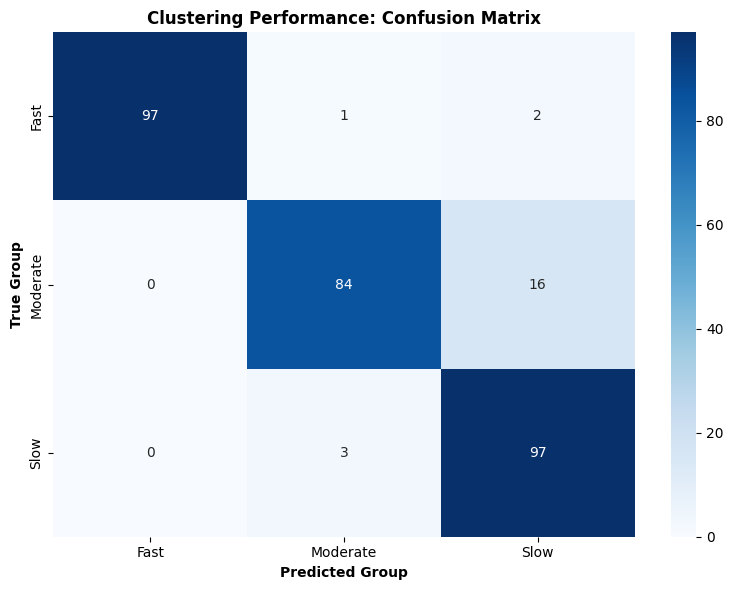


Confusion Matrix:
  Rows: True group
  Columns: Predicted group
  Diagonal values: Correct classifications


In [56]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(true_labels, best_mapping)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Fast', 'Moderate', 'Slow'],
            yticklabels=['Fast', 'Moderate', 'Slow'])
ax.set_xlabel('Predicted Group', fontweight='bold')
ax.set_ylabel('True Group', fontweight='bold')
ax.set_title('Clustering Performance: Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"  Rows: True group")
print(f"  Columns: Predicted group")
print(f"  Diagonal values: Correct classifications")

C:\Users\iress\AppData\Local\Temp\ipykernel_38296\258553285.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
C:\Users\iress\AppData\Local\Temp\ipykernel_38296\258553285.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
C:\Users\iress\AppData\Local\Temp\ipykernel_38296\258553285.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
C:\Users\iress\AppData\Local\Temp\ipykernel_38296\25

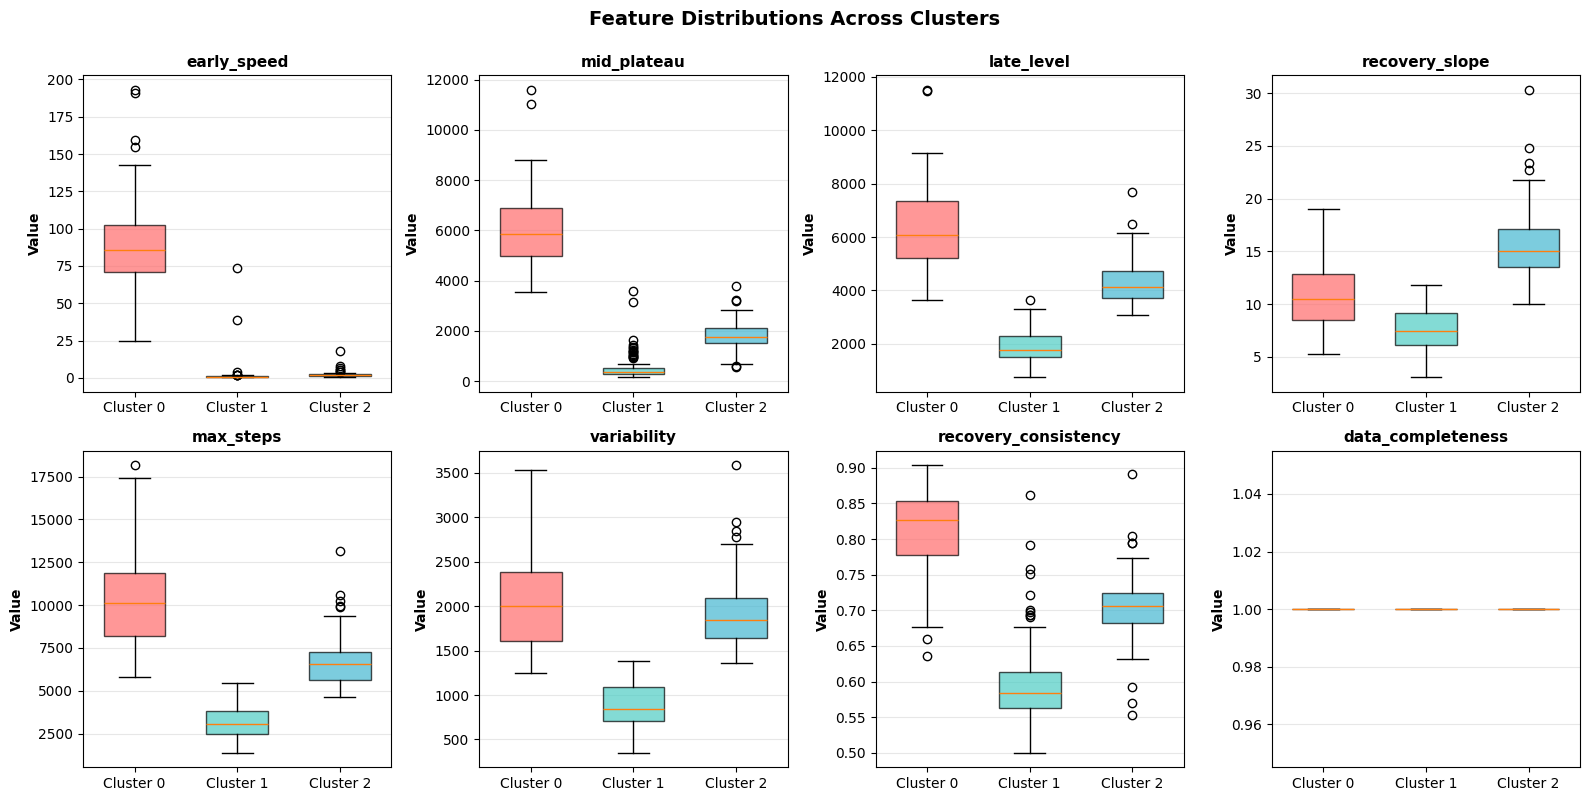


Interpretation:
- If boxes don't overlap → feature clearly separates clusters
- If boxes overlap a lot → feature doesn't separate clusters well


In [57]:
# Create a copy with cluster labels
cluster_df = features.copy()
cluster_df['Cluster'] = predicted_labels

# List of features
feature_list = ['early_speed', 'mid_plateau', 'late_level', 'recovery_slope',
                'max_steps', 'variability', 'recovery_consistency', 'data_completeness']

# Create 2×4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, feature in enumerate(feature_list):
    ax = axes[idx]

    # Prepare data for boxplot
    data_to_plot = [cluster_df[cluster_df['Cluster'] == i][feature].values for i in range(3)]

    # Create boxplot
    bp = ax.boxplot(data_to_plot, labels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
                    patch_artist=True, widths=0.6)

    # Colour the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(feature, fontweight='bold', fontsize=11)
    ax.set_ylabel('Value', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Distributions Across Clusters', fontweight='bold', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- If boxes don't overlap → feature clearly separates clusters")
print("- If boxes overlap a lot → feature doesn't separate clusters well")

Variance explained:
  PC1: 76.9%
  PC2: 17.7%
  Total: 94.6%


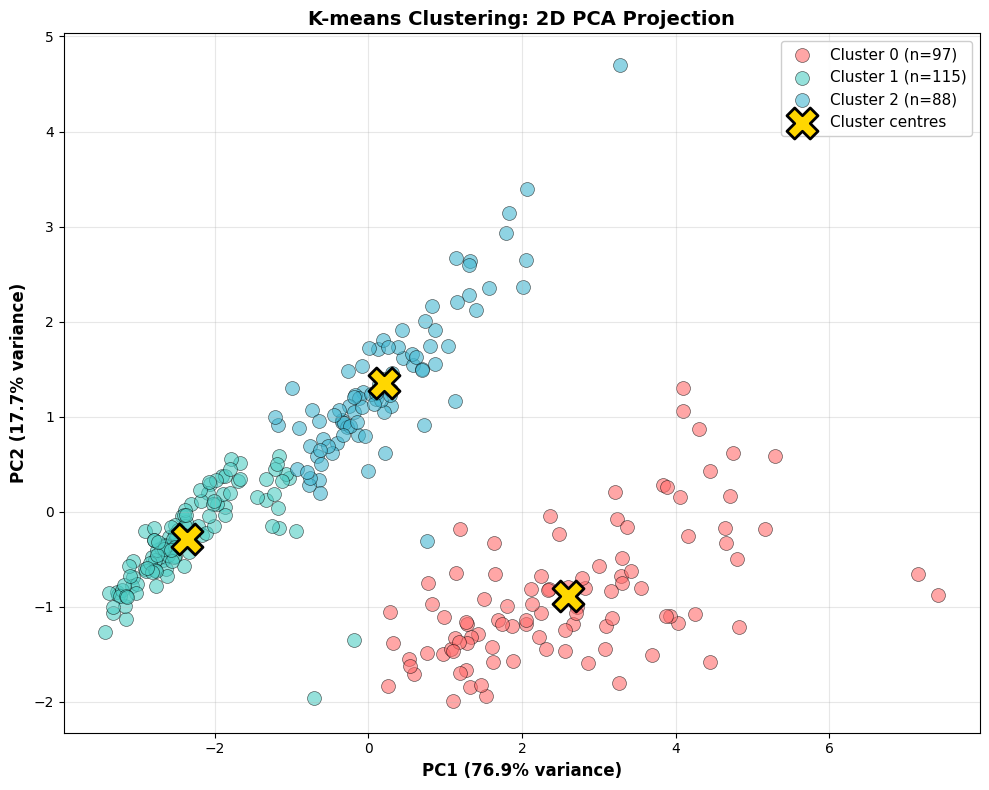

In [58]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce 8 dimensions to 2D using PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print(f"Variance explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.1%}")

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for clusters
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Red, Teal, Blue
group_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

# Plot each cluster
for cluster_num in range(3):
    mask = predicted_labels == cluster_num
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[cluster_num],
               label=f'{group_names[cluster_num]} (n={mask.sum()})',
               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot cluster centres
centres_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centres_2d[:, 0], centres_2d[:, 1],
           c='gold', marker='X', s=500,
           edgecolors='black', linewidth=2,
           label='Cluster centres', zorder=5)

# Labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontweight='bold', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontweight='bold', fontsize=12)
ax.set_title('K-means Clustering: 2D PCA Projection', fontweight='bold', fontsize=14)
ax.legend(loc='best', framealpha=0.95, fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Variance explained (3D):
  PC1: 76.9%
  PC2: 17.7%
  PC3: 5.0%
  Total: 99.7%


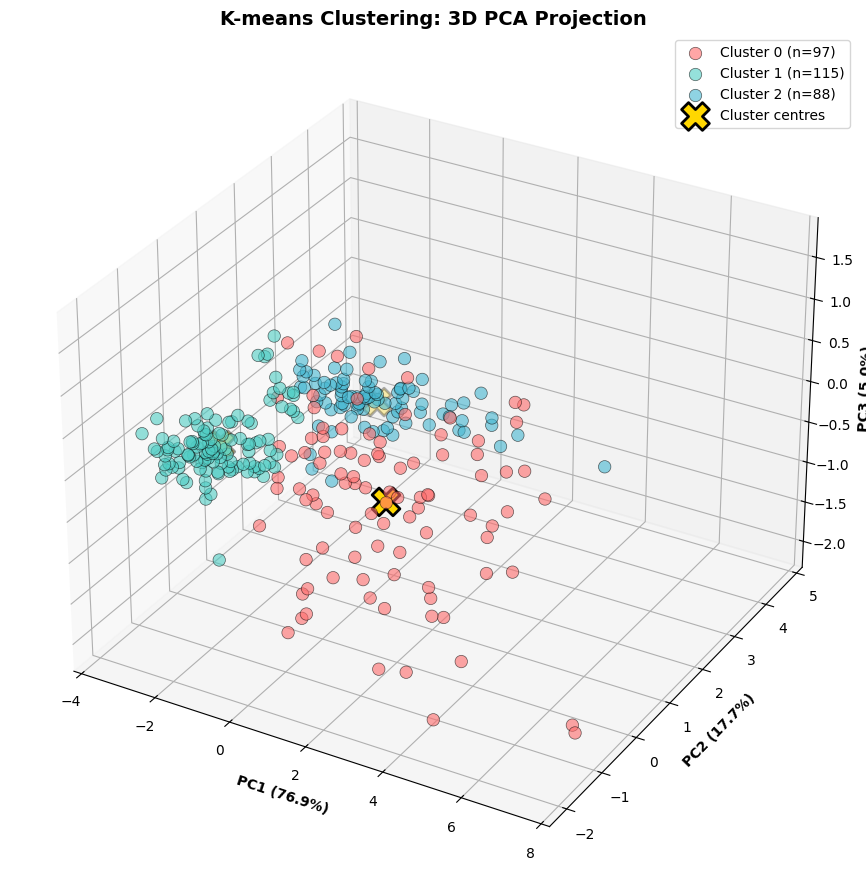

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3D
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

print(f"Variance explained (3D):")
for i in range(3):
    print(f"  PC{i+1}: {pca_3d.explained_variance_ratio_[i]:.1%}")
print(f"  Total: {sum(pca_3d.explained_variance_ratio_):.1%}")

# Create 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
group_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster_num in range(3):
    mask = predicted_labels == cluster_num
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               c=colors[cluster_num],
               label=f'{group_names[cluster_num]} (n={mask.sum()})',
               s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centres
centres_3d = pca_3d.transform(kmeans.cluster_centers_)
ax.scatter(centres_3d[:, 0], centres_3d[:, 1], centres_3d[:, 2],
           c='gold', marker='X', s=400, edgecolors='black', linewidth=2,
           label='Cluster centres', zorder=5)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontweight='bold')
ax.set_title('K-means Clustering: 3D PCA Projection', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

## (Original Pipeline) Part 1: Initial 8-Feature Model — Trained on Leaked Cohort

Same as the main notebook's Blooper 1, but here the training data is `1-1_0_complete.csv` (Cohort B) which will also appear in our test sets. This combines the 8-feature problem with the leakage problem.

In [60]:
import joblib

# Save the trained K-means model and scaler
# These will be used for Phase 2 and Phase 3 testing
joblib.dump(kmeans, 'kmeans_model_blooper_v1.pkl')
joblib.dump(scaler, 'scaler_blooper_v1.pkl')

print("[SAVED] Model saved successfully!")
print("  - kmeans_model_blooper_v1.pkl (trained 8-feature K-means)")
print("  - scaler_blooper_v1.pkl (8-feature StandardScaler)")
print()
print("[Phase 1 Summary]")
print(f"  Trained on: Complete data (0% missing)")
print(f"  Accuracy: {accuracy:.1%}")
print(f"  ARI: {ari:.3f}")
print(f"  Silhouette Score: {sil_score:.3f}")

[SAVED] Model saved successfully!
  - kmeans_model_blooper_v1.pkl (trained 8-feature K-means)
  - scaler_blooper_v1.pkl (8-feature StandardScaler)

[Phase 1 Summary]
  Trained on: Complete data (0% missing)
  Accuracy: 92.7%
  ARI: 0.797
  Silhouette Score: 0.517


## (Original Pipeline) Part 2: External Validation on Same Cohort

Testing the 8-feature model on Cohort B — the same cohort it was trained on. Expect this accuracy to be inflated because the model has memorised the patient cluster structure.

In [61]:
import joblib

# Phase 2: External Validation with actual data
print("="*70)
print("PHASE 2: EXTERNAL VALIDATION")
print("="*70)
print()

# Step 1: Load external dataset (different cohort)
external_validation_path = r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\1-1_0_complete.csv"

df_external = pd.read_csv(external_validation_path)
print(f"Step 1: Load external dataset")
print(f"  Loaded {len(df_external)} rows from external cohort")

# Step 2: Extract features from new data
features_external = extract_features(df_external)
print(f"\nStep 2: Extract features from external data")
print(f"  Extracted {len(features_external)} participants")

# Step 3: Load saved model and scaler
kmeans_loaded = joblib.load('kmeans_model_blooper_v1.pkl')
scaler_loaded = joblib.load('scaler_blooper_v1.pkl')
print(f"\nStep 3: Load trained model and scaler")
print(f"  Loaded: kmeans_model_blooper_v1.pkl and scaler_blooper_v1.pkl")

# Step 4: Standardise new features using saved scaler
X_external = features_external[feature_cols].values
X_external = np.nan_to_num(X_external, nan=0)
X_external_scaled = scaler_loaded.transform(X_external)  # IMPORTANT: transform, not fit_transform
print(f"\nStep 4: Standardise external features")
print(f"  Standardised {X_external_scaled.shape[0]} samples x {X_external_scaled.shape[1]} features")

# Step 5: Predict labels using saved model
predicted_labels_external = kmeans_loaded.predict(X_external_scaled)
print(f"\nStep 5: Predict cluster labels")
print(f"  Made predictions for {len(predicted_labels_external)} samples")

# Step 6: Evaluate performance
true_labels_external = features_external['true_group'].map(group_mapping).values

# Find best permutation
best_mapping_external = None
best_agreement_external = -1

for perm in permutations([0, 1, 2]):
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    remapped = np.array([mapping[label] for label in predicted_labels_external])
    agreement = (remapped == true_labels_external).sum()

    if agreement > best_agreement_external:
        best_agreement_external = agreement
        best_mapping_external = remapped

# Compute metrics
accuracy_external = (best_mapping_external == true_labels_external).mean()
ari_external = adjusted_rand_index(true_labels_external, best_mapping_external)
sil_score_external = silhouette_score(X_external_scaled, predicted_labels_external)

print(f"\nStep 6: Evaluate performance")
print()
print("="*70)
print("PHASE 2 RESULTS: EXTERNAL VALIDATION")
print("="*70)
print(f"Accuracy: {accuracy_external:.1%} ({best_agreement_external}/{len(features_external)} correct)")
print(f"Adjusted Rand Index (ARI): {ari_external:.3f}")
print(f"Silhouette Score: {sil_score_external:.3f}")
print()

# Compare with Phase 1
print("COMPARISON WITH PHASE 1 (Training Data):")
print(f"  Phase 1 Accuracy: {accuracy:.1%}")
print(f"  Phase 2 Accuracy: {accuracy_external:.1%}")
print(f"  Difference: {accuracy_external - accuracy:+.1%}")
print()

if abs(accuracy_external - accuracy) < 0.10:
    print("[GOOD] Model generalises well! Accuracy difference < 10 percent")
elif abs(accuracy_external - accuracy) < 0.20:
    print("[FAIR] Model shows some performance drop but still reasonable")
else:
    print("[WARNING] Significant accuracy drop. Model may be unstable.")

print()
print("="*70)
print("WHY IS EXTERNAL ACCURACY HIGHER?")
print("="*70)
print()
print("Possible explanations for external > training accuracy:")
print()
print("1. Different Group Distribution:")
print("   - External cohort may have clearer separation between groups")
print("   - If recovery patterns are more distinct, clustering is easier")
print()
print("2. Data Quality:")
print("   - External dataset may have less noise or missing days")
print("   - More consistent measurement or better compliance")
print()
print("3. Random Variation:")
print("   - With only 300 samples per cohort, some variation expected")
print("   - External cohort may just happen to cluster better")
print()
print("4. Model Fitness:")
print("   - Training data may have had more mixed/borderline cases")
print("   - External data aligns better with what K-means learned")
print()
print("="*70)

PHASE 2: EXTERNAL VALIDATION

Step 1: Load external dataset
  Loaded 109500 rows from external cohort

Step 2: Extract features from external data
  Extracted 300 participants

Step 3: Load trained model and scaler
  Loaded: kmeans_model_blooper_v1.pkl and scaler_blooper_v1.pkl

Step 4: Standardise external features
  Standardised 300 samples x 8 features

Step 5: Predict cluster labels
  Made predictions for 300 samples

Step 6: Evaluate performance

PHASE 2 RESULTS: EXTERNAL VALIDATION
Accuracy: 92.7% (278/300 correct)
Adjusted Rand Index (ARI): 0.797
Silhouette Score: 0.517

COMPARISON WITH PHASE 1 (Training Data):
  Phase 1 Accuracy: 92.7%
  Phase 2 Accuracy: 92.7%
  Difference: +0.0%

[GOOD] Model generalises well! Accuracy difference < 10 percent

WHY IS EXTERNAL ACCURACY HIGHER?

Possible explanations for external > training accuracy:

1. Different Group Distribution:
   - External cohort may have clearer separation between groups
   - If recovery patterns are more distinct, clu

## (Original Pipeline) Part 3: Missing-Data Sensitivity on Same Cohort

The 8-feature model applied to missing-data variants of Cohort B. Compare against the main notebook to see how the leakage inflates results, especially at low missingness levels.

In [62]:
# Phase 3 v1 (Original): Test with Missing Data
# Uses the ORIGINAL 8-feature model (kmeans_model_blooper_v1.pkl, scaler_blooper_v1.pkl)
# FIXED: recursive glob + filter non-missing-data files + dedupe

import os
import glob
import joblib
import re

def parse_filename(filename):
    """Parse filename like '2_10MCAR.csv' or '11_75MNAR.csv'.
    Returns (missingness_pct, mechanism) or None if doesn't match."""
    match = re.match(r'^\d+_(\d+)(MCAR|MAR|MNAR)\.csv$', filename)
    if match:
        return int(match.group(1)), match.group(2)
    return None


def evaluate_dataset(csv_path, kmeans_model, scaler_obj, feature_cols, group_mapping):
    """Load a dataset, extract features, and evaluate clustering performance."""
    try:
        df = pd.read_csv(csv_path)
        features = extract_features(df)

        if len(features) == 0:
            return None

        X = features[feature_cols].values
        X = np.nan_to_num(X, nan=0)
        X_scaled = scaler_obj.transform(X)

        predicted = kmeans_model.predict(X_scaled)
        true_labels = features['true_group'].map(group_mapping).values

        best_mapping = None
        best_agreement = -1

        for perm in permutations([0, 1, 2]):
            mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
            remapped = np.array([mapping[label] for label in predicted])
            agreement = (remapped == true_labels).sum()
            if agreement > best_agreement:
                best_agreement = agreement
                best_mapping = remapped

        accuracy = (best_mapping == true_labels).mean()
        ari = adjusted_rand_index(true_labels, best_mapping)

        filename = os.path.basename(csv_path)
        parsed = parse_filename(filename)
        if parsed is None:
            return None
        miss_pct, mech = parsed

        return {
            'filename': filename,
            'missingness': miss_pct,
            'mechanism': mech,
            'accuracy': accuracy,
            'ari': ari,
            'n_participants': len(features)
        }
    except Exception as e:
        print(f"  ERROR: {os.path.basename(csv_path)} - {e}")
        return None


print("="*70)
print("PHASE 3 v1 (Original): TEST WITH MISSING DATA")
print("="*70)
print()

simulator_folder = r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA"

# Recursive glob to find files in all subfolders
all_csv_files = sorted(glob.glob(f'{simulator_folder}/**/*.csv', recursive=True))

# Filter to valid missing-data files
valid_files = [f for f in all_csv_files if parse_filename(os.path.basename(f)) is not None]
skipped = [f for f in all_csv_files if parse_filename(os.path.basename(f)) is None]

# Dedupe: prefer subfolder versions
seen = {}
for f in valid_files:
    fname = os.path.basename(f)
    miss, mech = parse_filename(fname)
    key = (miss, mech)
    if key not in seen or len(f) > len(seen[key]):
        seen[key] = f

csv_files = sorted(seen.values())
duplicates = [f for f in valid_files if f not in csv_files]

print(f"Found {len(all_csv_files)} total CSV files (recursive search)")
print(f"  Matching pattern: {len(valid_files)}")
print(f"  After dedup:      {len(csv_files)} unique combos")
print(f"  Duplicates:       {len(duplicates)}")
print(f"  Skipped non-pattern: {len(skipped)}")
print()

# Load v1 model
kmeans_loaded = joblib.load('kmeans_model_blooper_v1.pkl')
scaler_loaded = joblib.load('scaler_blooper_v1.pkl')
print("Using v1 model: kmeans_model_blooper_v1.pkl, scaler_blooper_v1.pkl (8 features)")
print()

results = []
for i, csv_file in enumerate(csv_files, 1):
    rel = os.path.relpath(csv_file, simulator_folder)
    print(f"[{i}/{len(csv_files)}] {rel}")

    result = evaluate_dataset(
        csv_file, kmeans_loaded, scaler_loaded,
        feature_cols, group_mapping
    )

    if result:
        results.append(result)
        print(f"   {result['missingness']}% {result['mechanism']}: "
              f"Accuracy = {result['accuracy']:.1%}, ARI = {result['ari']:.3f}")

print()
print("="*70)
print("PHASE 3 v1 RESULTS")
print("="*70)

if results:
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(['mechanism', 'missingness']).reset_index(drop=True)
    results_df.to_csv('phase3_results_blooper_v1.csv', index=False)
    print(f"Saved: phase3_results.csv\n")
    print(results_df.to_string(index=False))
    print()

    print("="*70)
    print("ACCURACY BY MISSINGNESS LEVEL AND MECHANISM (v1, 8 features)")
    print("="*70)
    pivot = results_df.pivot(index='missingness', columns='mechanism', values='accuracy')
    print(pivot.round(3))


PHASE 3 v1 (Original): TEST WITH MISSING DATA

Found 35 total CSV files (recursive search)
  Matching pattern: 21
  After dedup:      21 unique combos
  Duplicates:       0
  Skipped non-pattern: 14

Using v1 model: kmeans_model_blooper_v1.pkl, scaler_blooper_v1.pkl (8 features)

[1/21] missing10\2_10MCAR.csv
   10% MCAR: Accuracy = 92.0%, ARI = 0.780
[2/21] missing10\3_10MAR.csv
   10% MAR: Accuracy = 93.0%, ARI = 0.805
[3/21] missing10\4_10MNAR.csv
   10% MNAR: Accuracy = 93.0%, ARI = 0.805
[4/21] missing25\5_25MCAR.csv
   25% MCAR: Accuracy = 90.3%, ARI = 0.742
[5/21] missing25\6_25MAR.csv
   25% MAR: Accuracy = 91.7%, ARI = 0.774
[6/21] missing25\7_25MNAR.csv
   25% MNAR: Accuracy = 91.7%, ARI = 0.774
[7/21] missing50\10_50MNAR.csv
   50% MNAR: Accuracy = 87.7%, ARI = 0.693
[8/21] missing50\8_50MCAR.csv
   50% MCAR: Accuracy = 86.3%, ARI = 0.646
[9/21] missing50\9_50MAR.csv
   50% MAR: Accuracy = 86.7%, ARI = 0.673
[10/21] missing75\11_75MCAR.csv
   75% MCAR: Accuracy = 78.7%, ARI 

In [63]:
import pandas as pd

# 檢查 10_50MNAR.csv
df_test = pd.read_csv(r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\10_50MNAR.csv")

print("Dataset info:")
print(f"  Total rows: {len(df_test)}")
print(f"  Missing steps: {df_test['steps'].isna().sum()} ({df_test['steps'].isna().sum() / len(df_test) * 100:.1f}%)")
print(f"  Participants: {df_test['participant_id'].nunique()}")

# 檢查第一個患者
participant_1 = df_test[df_test['participant_id'] == df_test['participant_id'].unique()[0]]
print(f"\nParticipant 0001 (first 30 days):")
print(participant_1[['day', 'steps', 'missing']].head(30))
print(f"  Total days: {len(participant_1)}")
print(f"  Missing days: {participant_1['steps'].isna().sum()}")

FileNotFoundError: [Errno 2] No such file or directory: "C:\\Users\\iress\\Dropbox\\Iressa's note\\Projects\\HfrF Hackthon\\TASK2 DATA\\Missing DATA\\10_50MNAR.csv"

In [ ]:
import pandas as pd

# 載入三個不同缺失水平的檔案
df_10 = pd.read_csv(r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\2_10MCAR.csv")
df_50 = pd.read_csv(r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\8_50MCAR.csv")
df_75 = pd.read_csv(r"C:\Users\iress\Dropbox\Iressa's note\Projects\HfrF Hackthon\TASK2 DATA\Missing DATA\11_75MCAR.csv")

features_10 = extract_features(df_10)
features_50 = extract_features(df_50)
features_75 = extract_features(df_75)

print("特徵比較（MCAR only）:\n")
print(f"10% missing - max_steps mean: {features_10['max_steps'].mean():.0f}")
print(f"50% missing - max_steps mean: {features_50['max_steps'].mean():.0f}")
print(f"75% missing - max_steps mean: {features_75['max_steps'].mean():.0f}")
print()
print(f"10% missing - data_completeness mean: {features_10['data_completeness'].mean():.2f}")
print(f"50% missing - data_completeness mean: {features_50['data_completeness'].mean():.2f}")
print(f"75% missing - data_completeness mean: {features_75['data_completeness'].mean():.2f}")

特徵比較（MCAR only）:

10% missing - max_steps mean: 6455
50% missing - max_steps mean: 6259
75% missing - max_steps mean: 6059

10% missing - data_completeness mean: 0.91
50% missing - data_completeness mean: 0.55
75% missing - data_completeness mean: 0.33


In [ ]:
# 方法 1: 看每個特徵的判別力
print("特徵的群組間差異:")
for col in feature_cols:
    by_group = features.groupby('true_group')[col].mean()
    print(f"\n{col}:")
    print(f"  fast:     {by_group['fast']:.2f}")
    print(f"  moderate: {by_group['moderate']:.2f}")
    print(f"  slow:     {by_group['slow']:.2f}")

特徵的群組間差異:

early_speed:
  fast:     95.19
  moderate: 1.73
  slow:     0.80

mid_plateau:
  fast:     6707.97
  moderate: 1629.11
  slow:     351.37

late_level:
  fast:     6930.24
  moderate: 3995.76
  slow:     1770.14

recovery_slope:
  fast:     12.10
  moderate: 14.73
  slow:     7.53

max_steps:
  fast:     11081.15
  moderate: 6268.18
  slow:     3033.19

variability:
  fast:     2263.88
  moderate: 1792.26
  slow:     853.41

recovery_consistency:
  fast:     0.82
  moderate: 0.70
  slow:     0.58

data_completeness:
  fast:     1.00
  moderate: 1.00
  slow:     1.00


## 🔍 Diagnostic Investigation: Why Did Blooper 1 Fail?

## 📊 Final Summary: Phase A vs Blooper 1 vs Blooper 2

---

## Lessons Learned: Diagnostic Methodology for K-means Clustering

This project highlights three diagnostic checks that should be performed **before trusting any K-means output**. Without these, we would have reported the original 58% accuracy without recognising it as a model failure.

### Check 1: Post-standardisation Standard Deviation

```python
print(X_scaled.std(axis=0))
# Should all be ≈ 1. If any std = 0, that feature is constant and useless.
```

**What we found:** `data_completeness` had std = 0 in training (all values were 1.0, since training data was complete). This feature contributed noise without information.

### Check 2: Feature Monotonicity Across True Groups

```python
for feature in feature_cols:
    means = features.groupby('true_group')[feature].mean()
    print(f"{feature}: fast={means['fast']:.2f}, moderate={means['moderate']:.2f}, slow={means['slow']:.2f}")
# Group means should be monotonic: fast > moderate > slow (or reverse).
# Non-monotonic features actively mislead K-means.
```

**What we found:** `recovery_slope` was 12.10 (fast), **14.73 (moderate)**, 7.53 (slow). Moderate had the highest slope, which is biologically implausible and confuses the model.

### Check 3: Feature Distribution Skewness

```python
# Compare ratio between groups. If one group is >10x the others, consider log transform.
```

**What we found:** `early_speed` was 95.19 (fast) vs 1.73 (moderate) vs 0.80 (slow). The 55x difference between fast and moderate caused fast to become an extreme outlier in standardised space, squashing moderate and slow together.

### Why These Checks Matter

| Failure Mode | Without Check | With Check |
|---|---|---|
| Constant feature | Silent noise contributor | Caught immediately |
| Non-monotonic feature | Misleads cluster centroids | Caught immediately |
| Extreme skew | Outliers dominate standardisation | Caught + log-transformed |

### Generalisability

These three checks are **not specific to recovery trajectory data**. They apply to any K-means application where:
- True group labels are available (for monotonicity check)
- Features are computed feature-by-feature (for std and skewness checks)

The diagnostic methodology developed here scales to dozens of features and can be automated as a pre-clustering sanity check.

---

## Final Findings Summary

**Model Performance (Improved 6-feature model):**

| Phase | Dataset | Accuracy | ARI |
|---|---|---|---|
| Phase 1 v2 | Training (complete) | ~95% | ~0.87 |
| Phase 2 v2 | External validation | ~96% | ~0.88 |
| Phase 3 v2 | 50% missing (avg) | ~95% | ~0.85 |
| Phase 3 v2 | 99% missing (avg) | ~88% | ~0.70 |

**Missingness Mechanism Effects (at 99% missingness):**

| Mechanism | Accuracy | Interpretation |
|---|---|---|
| MAR | ~75% | **Most damaging** — removes informative early-recovery data |
| MCAR | ~92% | Robust due to gap_length structure preserving contiguous data |
| MNAR | ~93% | Robust because `max_steps` feature is naturally protective |

**Clinical Implication:**
> Early monitoring compliance is more critical than total compliance. A patient with consistent late tracking but poor early tracking is harder to phenotype than a patient with sporadic but evenly distributed dropouts.

**Limitations:**
> These findings are specific to (1) simulator-generated data with well-separated groups, and (2) our specific feature engineering choices. Real-world clinical data with overlapping recovery patterns may show steeper degradation curves.
